In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

DATASET_DIR   = "/content/drive/MyDrive/dataset"
SAVE_DIR      = "/content/drive/MyDrive/EEG_results_v2"

FEATURES_FILE       = f"{SAVE_DIR}/features_song.npz"
MELSPEC_FILE        = f"{SAVE_DIR}/melspec_song.npz"
MELSPEC_PARTIAL     = f"{SAVE_DIR}/melspec_song_partial.npz"

CKPT_CNN            = f"{SAVE_DIR}/best_cnn_lstm.pth"
CKPT_CNN_RESUME     = f"{SAVE_DIR}/resume_cnn_lstm.pth"
CKPT_RESNET         = f"{SAVE_DIR}/best_resnet.pth"
CKPT_RESNET_RESUME  = f"{SAVE_DIR}/resume_resnet.pth"
SCALER_FILE         = f"{SAVE_DIR}/scaler.pkl"
ENCODER_FILE        = f"{SAVE_DIR}/label_encoder.pkl"
SPLITS_FILE         = f"{SAVE_DIR}/data_splits.npz"
IMG_SPLITS_FILE     = f"{SAVE_DIR}/img_splits.npz"

os.makedirs(SAVE_DIR, exist_ok=True)
print("Save dir ready:", SAVE_DIR)

Save dir ready: /content/drive/MyDrive/EEG_results_v2


In [3]:
!pip install mne scikit-learn matplotlib seaborn scipy tqdm \
             imbalanced-learn librosa torchvision Pillow psutil --quiet
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 70.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
Done!


In [4]:
import warnings, glob, random, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from collections import Counter
import psutil

import mne
from scipy.signal import welch
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import librosa
import librosa.display
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"PyTorch : {torch.__version__}")

def ram_usage():
    vm = psutil.virtual_memory()
    print(f"RAM: {vm.used/1e9:.1f} GB used / {vm.total/1e9:.1f} GB total  ({vm.percent}%)")

ram_usage()
print("All imports OK")

Device  : cuda
GPU     : Tesla T4
PyTorch : 2.10.0+cu128
RAM: 1.3 GB used / 13.6 GB total  (12.2%)
All imports OK


In [5]:
NUM_SUBJECTS = 20
NUM_SONGS    = 12
EPOCH_SEC    = 4.0
OVERLAP_SEC  = 2.0

SESSION_TO_SONG = {f"ses-{i:02d}": f"song_{i:02d}" for i in range(1, 13)}

BANDS = {
    "delta": (1,  4),
    "theta": (4,  8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 50),
}
print("Config ready")

Config ready


In [6]:
def find_eeg_files(root, max_subjects=20):
    subject_folders = sorted([
        d for d in os.listdir(root)
        if d.startswith("sub-") and os.path.isdir(os.path.join(root, d))
    ])[:max_subjects]
    files = []
    for subj in subject_folders:
        subj_path = os.path.join(root, subj)
        for ses_name, song_label in SESSION_TO_SONG.items():
            ses_path = os.path.join(subj_path, ses_name, "eeg")
            if not os.path.isdir(ses_path): continue
            for ext in ["*.set", "*.fif", "*.edf", "*.bdf"]:
                for f in glob.glob(os.path.join(ses_path, ext)):
                    files.append((f, song_label))
    print(f"Subjects : {len(subject_folders)}")
    print(f"EEG files: {len(files)}")
    return files


def preprocess_and_epoch(filepath):
    ext = Path(filepath).suffix.lower()
    loaders = {
        ".set": mne.io.read_raw_eeglab,
        ".fif": mne.io.read_raw_fif,
        ".edf": mne.io.read_raw_edf,
        ".bdf": mne.io.read_raw_bdf,
    }
    raw = loaders.get(ext, mne.io.read_raw_eeglab)(filepath, preload=True, verbose=False)
    raw.pick("eeg", verbose=False)
    raw.set_eeg_reference("average", projection=True, verbose=False)
    raw.apply_proj()
    raw.filter(1.0, 50.0, method="fir", verbose=False)
    raw.notch_filter(50.0, verbose=False)
    epochs = mne.make_fixed_length_epochs(
        raw, duration=EPOCH_SEC, overlap=OVERLAP_SEC, preload=True, verbose=False)
    return epochs


def extract_features(epoch_data, sfreq):
    n_ch, n_t = epoch_data.shape
    feats = []
    freqs, psd = welch(epoch_data, fs=sfreq, nperseg=min(256, n_t), axis=-1)
    band_powers = {}
    for name, (lo, hi) in BANDS.items():
        idx = (freqs >= lo) & (freqs <= hi)
        bp  = psd[:, idx].mean(axis=-1)
        band_powers[name] = bp
        feats.append(bp)
    feats.append(band_powers["theta"] / (band_powers["alpha"] + 1e-12))
    feats.append(band_powers["alpha"] / (band_powers["beta"]  + 1e-12))
    feats.append(epoch_data.mean(axis=-1))
    feats.append(epoch_data.std(axis=-1))
    feats.append(skew(epoch_data, axis=-1))
    feats.append(kurtosis(epoch_data, axis=-1))
    feats.append(np.ptp(epoch_data, axis=-1))
    d1 = np.diff(epoch_data, axis=-1)
    d2 = np.diff(d1, axis=-1)
    activity   = epoch_data.var(axis=-1)
    mobility   = np.sqrt(d1.var(axis=-1) / (activity + 1e-12))
    complexity = np.sqrt(d2.var(axis=-1) / (d1.var(axis=-1) + 1e-12)) / (mobility + 1e-12)
    feats.append(activity)
    feats.append(mobility)
    feats.append(complexity)
    return np.stack(feats, axis=1).flatten().astype(np.float32)


def epoch_to_melspec(epoch_data, sfreq, img_size=224):
    signal     = epoch_data.mean(axis=0).astype(np.float32)
    n_fft      = min(256, len(signal))
    hop_length = min(32, n_fft // 2)
    fmax_safe  = min(50.0, sfreq / 2.0 - 1.0)
    mel    = librosa.feature.melspectrogram(
        y=signal, sr=int(sfreq), n_mels=64,
        hop_length=hop_length, n_fft=n_fft,
        fmin=1.0, fmax=fmax_safe)
    mel_db   = librosa.power_to_db(mel, ref=np.max)
    mel_norm = ((mel_db - mel_db.min()) /
                (mel_db.max() - mel_db.min() + 1e-12) * 255).astype(np.uint8)
    resample = getattr(Image, "Resampling", Image).BILINEAR
    img = Image.fromarray(mel_norm).resize((img_size, img_size), resample).convert("RGB")
    return np.array(img).transpose(2, 0, 1).astype(np.float32) / 255.0


eeg_files = find_eeg_files(DATASET_DIR, NUM_SUBJECTS)
print("Helper functions ready")

Subjects : 20
EEG files: 240
Helper functions ready


In [7]:
if os.path.exists(FEATURES_FILE):
    print("Loading cached features...")
    saved = np.load(FEATURES_FILE, allow_pickle=True)
    X, y_raw = saved["X"], saved["y_raw"]
else:
    print(f"Extracting features from {len(eeg_files)} files...")
    all_features, all_labels = [], []
    for idx, (fpath, song_label) in enumerate(eeg_files):
        fname = Path(fpath).name
        print(f"[{idx+1}/{len(eeg_files)}] {fname}", end=" ... ")
        try:
            epochs = preprocess_and_epoch(fpath)
            if len(epochs) == 0: print("skipped (0 epochs)"); continue
            sfreq = epochs.info["sfreq"]
            data  = epochs.get_data()
            feats = np.array([extract_features(ep, sfreq) for ep in data])
            all_features.append(feats)
            all_labels.extend([song_label] * len(data))
            print(f"{len(data)} epochs")
            del epochs, data, feats
            gc.collect()
        except Exception as e:
            print(f"skipped ({e})")
    X     = np.vstack(all_features)
    y_raw = np.array(all_labels)
    np.savez(FEATURES_FILE, X=X, y_raw=y_raw)
    print(f"Saved to {FEATURES_FILE}")
    del all_features, all_labels
    gc.collect()

le = LabelEncoder()
y  = le.fit_transform(y_raw)
joblib.dump(le, ENCODER_FILE)
print(f"Samples  : {X.shape[0]}")
print(f"Features : {X.shape[1]}")
print(f"Classes  : {list(le.classes_)}")
ram_usage()


Loading cached features...
Samples  : 15200
Features : 1935
Classes  : [np.str_('song_01'), np.str_('song_02'), np.str_('song_03'), np.str_('song_04'), np.str_('song_05'), np.str_('song_06'), np.str_('song_07'), np.str_('song_08'), np.str_('song_09'), np.str_('song_10'), np.str_('song_11'), np.str_('song_12')]
RAM: 1.5 GB used / 13.6 GB total  (13.5%)


In [8]:
if os.path.exists(SPLITS_FILE):
    print("Loading cached splits...")
    sp   = np.load(SPLITS_FILE, allow_pickle=True)
    X_tr, X_va, X_te = sp["X_tr"], sp["X_va"], sp["X_te"]
    y_tr, y_va, y_te = sp["y_tr"], sp["y_va"], sp["y_te"]
    scaler = joblib.load(SCALER_FILE)
else:
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    joblib.dump(scaler, SCALER_FILE)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.15, stratify=y, random_state=SEED)
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=SEED)
    np.savez(SPLITS_FILE, X_tr=X_tr, X_va=X_va, X_te=X_te,
             y_tr=y_tr, y_va=y_va, y_te=y_te)
    print(f"Splits saved.")
    del X_scaled
    gc.collect()

# Free raw X now that splits are ready — no longer needed
del X
gc.collect()

print(f"Train: {len(X_tr)}  Val: {len(X_va)}  Test: {len(X_te)}")
ram_usage()


Loading cached splits...
Train: 10982  Val: 1938  Test: 2280
RAM: 1.5 GB used / 13.6 GB total  (13.5%)


In [9]:
# ── CELL 9: Cleanup old files from Drive ─────────────────────────────────────
import os

# Files to delete — old CNN-LSTM and ResNet/EfficientNet stuff
files_to_delete = [
    CKPT_CNN,              # best_cnn_lstm.pth
    CKPT_CNN_RESUME,       # resume_cnn_lstm.pth
    CKPT_RESNET,           # best_resnet.pth
    CKPT_RESNET_RESUME,    # resume_resnet.pth
    f"{SAVE_DIR}/final_results.png",
    f"{SAVE_DIR}/model_comparison.png",
    f"{SAVE_DIR}/training_curves.png",
    f"{SAVE_DIR}/confusion_matrices.png",
    f"{SAVE_DIR}/mel_samples.png",
]

print("Deleting old files...")
for f in files_to_delete:
    if os.path.exists(f):
        os.remove(f)
        print(f"  ✅ Deleted: {os.path.basename(f)}")
    else:
        print(f"  ⚠️  Not found: {os.path.basename(f)}")

# Files to KEEP — data we still need
keep = [FEATURES_FILE, MELSPEC_FILE, SCALER_FILE,
        ENCODER_FILE, SPLITS_FILE]
print("\nKeeping:")
for f in keep:
    exists = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f"  {exists} {os.path.basename(f)}")

print("\nDrive cleaned up — ready for FBCL-Net!")

Deleting old files...
  ✅ Deleted: best_cnn_lstm.pth
  ✅ Deleted: resume_cnn_lstm.pth
  ⚠️  Not found: best_resnet.pth
  ⚠️  Not found: resume_resnet.pth
  ⚠️  Not found: final_results.png
  ⚠️  Not found: model_comparison.png
  ⚠️  Not found: training_curves.png
  ⚠️  Not found: confusion_matrices.png
  ⚠️  Not found: mel_samples.png

Keeping:
  ✅ features_song.npz
  ❌ MISSING melspec_song.npz
  ✅ scaler.pkl
  ✅ label_encoder.pkl
  ✅ data_splits.npz

Drive cleaned up — ready for FBCL-Net!


In [10]:
# ── CELL 9: Split features into semantic groups ───────────────────────────────
N_CH = 129  # number of EEG channels

# Feature group indices (based on extract_features order)
FEAT_GROUPS = {
    "band_power" : (0,          5 * N_CH),  # delta, theta, alpha, beta, gamma
    "ratios"     : (5 * N_CH,   7 * N_CH),  # theta/alpha, alpha/beta
    "time_stats" : (7 * N_CH,  12 * N_CH),  # mean, std, skew, kurt, ptp
    "hjorth"     : (12 * N_CH, 15 * N_CH),  # activity, mobility, complexity
}

def split_features(X):
    """Split flat feature vector into semantic groups."""
    return {name: X[:, s:e] for name, (s, e) in FEAT_GROUPS.items()}

# Verify
splits = split_features(X_tr)
print("Feature group sizes:")
for name, arr in splits.items():
    print(f"  {name:12s}: {arr.shape}")
print(f"  Total        : {sum(a.shape[1] for a in splits.values())}")

Feature group sizes:
  band_power  : (10982, 645)
  ratios      : (10982, 258)
  time_stats  : (10982, 645)
  hjorth      : (10982, 387)
  Total        : 1935


In [11]:
# ── CELL 10: FBCL-Net Architecture ───────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F

N_CH = 129
FEAT_SIZES = {
    "band_power" : 5 * N_CH,   # 645
    "ratios"     : 2 * N_CH,   # 258
    "time_stats" : 5 * N_CH,   # 645
    "hjorth"     : 3 * N_CH,   # 387
}
N_BANDS = 5  # delta, theta, alpha, beta, gamma

# ── 1. Band Attention Module ──────────────────────────────────────────────────
class BandAttention(nn.Module):
    """
    Learns which frequency band matters most.
    Input : (B, 5, N_CH) — 5 band power maps
    Output: (B, N_CH)    — weighted sum across bands
    Also returns attention weights for visualization.
    """
    def __init__(self, n_ch=N_CH, n_bands=N_BANDS):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(n_bands * n_ch, 128),
            nn.GELU(),
            nn.Linear(128, n_bands),
        )

    def forward(self, x):
        # x: (B, n_bands, n_ch)
        B = x.size(0)
        flat = x.view(B, -1)                          # (B, n_bands*n_ch)
        w    = torch.softmax(self.attn(flat), dim=-1) # (B, n_bands)
        out  = (x * w.unsqueeze(-1)).sum(dim=1)       # (B, n_ch)
        return out, w  # return weights for visualization

# ── 2. Branch Encoder (shared structure, different sizes) ─────────────────────
class BranchEncoder(nn.Module):
    """
    Encodes one feature group into a fixed-size embedding.
    Uses residual MLP for stable training.
    """
    def __init__(self, in_dim, out_dim=256, dropout=0.3):
        super().__init__()
        mid = max(in_dim // 2, out_dim)
        self.net = nn.Sequential(
            nn.Linear(in_dim, mid),
            nn.LayerNorm(mid),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mid, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
        )
        # Residual projection if sizes differ
        self.res = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        return self.net(x) + self.res(x)

# ── 3. Temporal Encoder (CNN-LSTM on full features) ───────────────────────────
class ResBlock1D(nn.Module):
    def __init__(self, ch, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(ch, ch, 3, padding=1), nn.BatchNorm1d(ch),
            nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(ch, ch, 3, padding=1), nn.BatchNorm1d(ch),
        )
        self.act = nn.GELU()
    def forward(self, x): return self.act(x + self.block(x))

class TemporalEncoder(nn.Module):
    """CNN-LSTM on full feature vector — captures temporal dynamics."""
    def __init__(self, in_dim=1935, out_dim=256, dropout=0.4):
        super().__init__()
        self.proj = nn.Linear(in_dim, 512)
        self.cnn  = nn.Sequential(
            nn.Conv1d(1, 64,  7, padding=3), nn.BatchNorm1d(64),  nn.GELU(),
            ResBlock1D(64),  ResBlock1D(64),
            nn.Conv1d(64, 128, 3, stride=2, padding=1), nn.GELU(),
            ResBlock1D(128), ResBlock1D(128),
            nn.Conv1d(128, 256, 3, stride=2, padding=1), nn.GELU(),
            ResBlock1D(256),
        )
        self.lstm = nn.LSTM(256, 256, num_layers=2, batch_first=True,
                            dropout=dropout, bidirectional=True)
        # Attention pooling
        self.attn_pool = nn.Linear(512, 1)
        self.out_proj   = nn.Linear(512, out_dim)

    def forward(self, x):
        x = self.proj(x).unsqueeze(1)           # (B, 1, 512)
        x = self.cnn(x).permute(0, 2, 1)        # (B, T, 256)
        x, _ = self.lstm(x)                      # (B, T, 512)
        w = torch.softmax(self.attn_pool(x), dim=1)  # (B, T, 1)
        x = (x * w).sum(dim=1)                  # (B, 512)
        return self.out_proj(x)                  # (B, 256)

# ── 4. FBCL-Net (Full Model) ──────────────────────────────────────────────────
class FBCLNet(nn.Module):
    """
    Frequency-Band Contrastive Learning Network.

    Three branches:
      1. Band Attention  — weighted frequency band fusion
      2. Feature Branches — hjorth + stats encoders
      3. Temporal CNN-LSTM — full feature dynamics

    Trained with CrossEntropy + Supervised Contrastive Loss.
    """
    def __init__(self, n_classes, n_ch=N_CH, proj_dim=128, dropout=0.4):
        super().__init__()

        # Branch 1: Band attention on band-power features
        self.band_attn    = BandAttention(n_ch=n_ch, n_bands=N_BANDS)
        self.band_encoder = BranchEncoder(n_ch, 256, dropout)

        # Branch 2: Ratio + stats encoder
        self.stat_encoder   = BranchEncoder(FEAT_SIZES["time_stats"] +
                                            FEAT_SIZES["ratios"], 256, dropout)

        # Branch 3: Hjorth encoder
        self.hjorth_encoder = BranchEncoder(FEAT_SIZES["hjorth"], 128, dropout)

        # Branch 4: Full temporal CNN-LSTM
        self.temporal       = TemporalEncoder(1935, 256, dropout)

        # Fusion gate — learns how much to trust each branch
        fused_dim = 256 + 256 + 128 + 256   # = 896
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Projection head for contrastive loss (separate from classifier)
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Linear(256, proj_dim),
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x, return_projection=False):
        # ── Branch 1: Band attention ──
        bp = x[:, 0 : 5*N_CH].view(-1, N_BANDS, N_CH)   # (B, 5, 129)
        band_feat, band_weights = self.band_attn(bp)       # (B, 129), (B, 5)
        band_feat = self.band_encoder(band_feat)           # (B, 256)

        # ── Branch 2: Stats + ratios ──
        stat_in   = torch.cat([
            x[:, 5*N_CH : 7*N_CH],   # ratios
            x[:, 7*N_CH : 12*N_CH],  # time stats
        ], dim=-1)
        stat_feat = self.stat_encoder(stat_in)             # (B, 256)

        # ── Branch 3: Hjorth ──
        hjorth_feat = self.hjorth_encoder(x[:, 12*N_CH:]) # (B, 128)

        # ── Branch 4: Temporal ──
        temp_feat = self.temporal(x)                       # (B, 256)

        # ── Fusion ──
        fused = torch.cat([band_feat, stat_feat,
                           hjorth_feat, temp_feat], dim=-1)  # (B, 896)
        fused = self.fusion(fused)                            # (B, 512)

        logits = self.classifier(fused)                       # (B, n_classes)

        if return_projection:
            proj = F.normalize(self.projector(fused), dim=-1) # (B, proj_dim)
            return logits, proj, band_weights

        return logits

n_classes = len(le.classes_)
fbcl = FBCLNet(n_classes=n_classes).to(DEVICE)
print(f"FBCL-Net params: {sum(p.numel() for p in fbcl.parameters()):,}")

FBCL-Net params: 6,401,334


In [12]:
# ── CELL 11: Supervised Contrastive Loss ─────────────────────────────────────
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss (Khosla et al. 2020).
    Pulls same-class embeddings together,
    pushes different-class embeddings apart.
    This reduces cross-subject variability in EEG.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temp = temperature

    def forward(self, features, labels):
        # features: (B, proj_dim) — L2 normalized
        # labels  : (B,)
        B = features.size(0)
        labels  = labels.contiguous().view(-1, 1)           # (B, 1)
        mask    = torch.eq(labels, labels.T).float().to(DEVICE)  # (B, B)

        # Compute similarity matrix
        sim = torch.matmul(features, features.T) / self.temp  # (B, B)

        # Remove self-similarity from denominator
        self_mask = torch.eye(B, dtype=torch.bool).to(DEVICE)
        sim.masked_fill_(self_mask, float("-inf"))

        # Log-softmax over similarities
        log_prob = F.log_softmax(sim, dim=-1)

        # Mask out self from positives
        mask.masked_fill_(self_mask, 0)

        # Mean log-probability over positives
        pos_count = mask.sum(dim=-1).clamp(min=1)
        loss = -(mask * log_prob).sum(dim=-1) / pos_count
        return loss.mean()

supcon = SupConLoss(temperature=0.07)
print("SupConLoss ready")

SupConLoss ready


In [14]:
# ── CELL 12: FBCL-Net Training ───────────────────────────────────────────────
from torch.optim.lr_scheduler import LambdaLR

# ── Dataset class (needed for DataLoaders) ────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_tr, y_tr), batch_size=128,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(EEGDataset(X_va, y_va), batch_size=256,
                          shuffle=False, num_workers=0, pin_memory=True)

# ── Loss weights ──────────────────────────────────────────────────────────────
LAMBDA_CON = 0.3

cw        = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
ce_loss   = nn.CrossEntropyLoss(
    weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE),
    label_smoothing=0.1)

optimizer = optim.AdamW(fbcl.parameters(), lr=3e-4, weight_decay=1e-4)

def lr_lambda(ep):
    if ep < 5: return (ep + 1) / 5.0
    return 0.5 * (1 + np.cos(np.pi * (ep - 5) / 115))

scheduler = LambdaLR(optimizer, lr_lambda)

CKPT_FBCL        = f"{SAVE_DIR}/best_fbcl.pth"
CKPT_FBCL_RESUME = f"{SAVE_DIR}/resume_fbcl.pth"

best_val  = 0.0
no_imp    = 0
patience  = 20
start_ep  = 1
history   = {"train_loss": [], "val_loss": [],
             "train_acc":  [], "val_acc":  [],
             "con_loss":   []}

if os.path.exists(CKPT_FBCL_RESUME):
    print("Found FBCL resume checkpoint — loading...")
    chk = torch.load(CKPT_FBCL_RESUME, map_location=DEVICE)
    fbcl.load_state_dict(chk["model_state_dict"])
    optimizer.load_state_dict(chk["optimizer_state_dict"])
    scheduler.load_state_dict(chk["scheduler_state_dict"])
    best_val = chk["best_val"]
    no_imp   = chk["no_imp"]
    history  = chk["history"]
    start_ep = chk["epoch"] + 1
    print(f"Resuming from epoch {start_ep} (best val: {best_val:.2%})")
else:
    print("Starting FBCL-Net training from scratch")

print(f"{'Ep':>4}  {'TrLoss':>8}  {'ConLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}")
print("-" * 60)

for ep in range(start_ep, 121):

    # ── Train ──
    fbcl.train()
    tl, tc, tt, tcl = 0.0, 0, 0, 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()

        logits, proj, _ = fbcl(X_b, return_projection=True)

        loss_ce  = ce_loss(logits, y_b)
        loss_con = supcon(proj, y_b)
        loss     = loss_ce + LAMBDA_CON * loss_con

        loss.backward()
        torch.nn.utils.clip_grad_norm_(fbcl.parameters(), 1.0)
        optimizer.step()

        tl  += loss_ce.item()  * len(y_b)
        tcl += loss_con.item() * len(y_b)
        tc  += (logits.argmax(1) == y_b).sum().item()
        tt  += len(y_b)
    scheduler.step()

    # ── Validate ──
    fbcl.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits   = fbcl(X_b)
            loss     = ce_loss(logits, y_b)
            vl += loss.item() * len(y_b)
            vc += (logits.argmax(1) == y_b).sum().item()
            vt += len(y_b)

    tr_l, tr_a = tl/tt,  tc/tt
    cl_l       = tcl/tt
    va_l, va_a = vl/vt,  vc/vt

    history["train_loss"].append(tr_l)
    history["val_loss"].append(va_l)
    history["train_acc"].append(tr_a)
    history["val_acc"].append(va_a)
    history["con_loss"].append(cl_l)

    tag = ""
    if va_a > best_val:
        best_val = va_a; no_imp = 0
        torch.save(fbcl.state_dict(), CKPT_FBCL); tag = "★ BEST"
    else:
        no_imp += 1

    if ep % 5 == 0:
        torch.save({
            "epoch":                ep,
            "model_state_dict":     fbcl.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val":             best_val,
            "no_imp":               no_imp,
            "history":              history,
        }, CKPT_FBCL_RESUME)

    if ep % 5 == 0 or tag:
        print(f"{ep:>4}  {tr_l:>8.4f}  {cl_l:>8.4f}  {tr_a:>7.2%}  "
              f"{va_l:>8.4f}  {va_a:>7.2%}  {tag}")

    if no_imp >= patience:
        print(f"\nEarly stop at epoch {ep}")
        torch.save({
            "epoch":                ep,
            "model_state_dict":     fbcl.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val":             best_val,
            "no_imp":               no_imp,
            "history":              history,
        }, CKPT_FBCL_RESUME)
        break

print(f"\nBest Val Accuracy (FBCL-Net): {best_val:.2%}")
ram_usage()

Starting FBCL-Net training from scratch
  Ep    TrLoss   ConLoss    TrAcc    VaLoss    VaAcc
------------------------------------------------------------
   1    2.4911       nan    9.94%    2.4627   14.86%  ★ BEST
   2    2.4518       nan   12.99%    2.4049   16.72%  ★ BEST
   4    2.2350       nan   24.90%    2.2104   24.51%  ★ BEST
   5    2.0880       nan   31.16%    2.1224   29.82%  ★ BEST
   6    1.9315       nan   38.71%    2.0204   33.80%  ★ BEST
   7    1.7989       nan   44.05%    1.9574   38.13%  ★ BEST
   9    1.5831       nan   53.94%    1.7610   45.92%  ★ BEST
  10    1.4761       nan   59.32%    1.8767   42.98%  
  11    1.3993       nan   62.99%    1.7700   47.42%  ★ BEST
  13    1.2894       nan   68.09%    1.7645   47.63%  ★ BEST
  14    1.2128       nan   72.23%    1.5245   57.89%  ★ BEST
  15    1.1725       nan   73.90%    1.6038   54.18%  
  20    0.9894       nan   82.89%    1.7227   53.41%  
  22    0.9536       nan   84.03%    1.5548   59.91%  ★ BEST
  23    0.

In [17]:
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              classification_report, confusion_matrix)

# ── Redefine classes needed for loading ──────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

class ResBlock(nn.Module):
    def __init__(self, ch, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(ch, ch, 3, padding=1), nn.BatchNorm1d(ch),
            nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(ch, ch, 3, padding=1), nn.BatchNorm1d(ch),
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.block(x))

class EEGLSTM(nn.Module):
    def __init__(self, in_features, n_classes, dropout=0.4):
        super().__init__()
        self.proj = nn.Linear(in_features, 512)
        self.cnn  = nn.Sequential(
            nn.Conv1d(1, 64, 7, padding=3), nn.BatchNorm1d(64), nn.GELU(),
            ResBlock(64), ResBlock(64),
            nn.Conv1d(64, 128, 3, stride=2, padding=1), nn.GELU(),
            ResBlock(128), ResBlock(128),
        )
        self.lstm = nn.LSTM(128, 256, num_layers=2, batch_first=True,
                            dropout=dropout, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        x = self.proj(x).unsqueeze(1)
        x = self.cnn(x).permute(0, 2, 1)
        x, _ = self.lstm(x)
        x = x.mean(dim=1)
        return self.head(x)

# ── DataLoader ────────────────────────────────────────────────────────────────
test_loader = DataLoader(EEGDataset(X_te, y_te), batch_size=256,
                         shuffle=False, num_workers=0)

# ── FBCL-Net predictions ──────────────────────────────────────────────────────
fbcl.load_state_dict(torch.load(CKPT_FBCL, map_location=DEVICE))
fbcl.eval()
fbcl_preds, fbcl_true = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        fbcl_preds.extend(fbcl(X_b.to(DEVICE)).argmax(1).cpu().numpy())
        fbcl_true.extend(y_b.numpy())

# ── CNN-LSTM predictions (reload from checkpoint) ─────────────────────────────
import os # Added import for os module

cnn_preds, cnn_true = None, None # Initialize to None in case CNN model is skipped
m_cnn = {"Accuracy": 0.0, "F1 (macro)": 0.0, "Precision": 0.0, "Recall": 0.0} # Initialize m_cnn

if os.path.exists(CKPT_CNN):
    n_classes = len(le.classes_)
    cnn_model = EEGLSTM(X_tr.shape[1], n_classes).to(DEVICE)
    cnn_model.load_state_dict(torch.load(CKPT_CNN, map_location=DEVICE))
    cnn_model.eval()
    cnn_preds, cnn_true = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            cnn_preds.extend(cnn_model(X_b.to(DEVICE)).argmax(1).cpu().numpy())
            cnn_true.extend(y_b.numpy())
    # Free CNN model from GPU
    del cnn_model
    torch.cuda.empty_cache()
    print("CNN-LSTM model loaded and evaluated.")
else:
    print(f"Warning: CNN-LSTM checkpoint not found at {CKPT_CNN}. Skipping CNN-LSTM evaluation.")

# ── Metrics ───────────────────────────────────────────────────────────────────
def get_metrics(true, preds):
    if true is None or preds is None:
        return {
            "Accuracy": 0.0,
            "F1 (macro)": 0.0,
            "Precision": 0.0,
            "Recall": 0.0,
        }
    return {
        "Accuracy"  : accuracy_score(true, preds)                    * 100,
        "F1 (macro)": f1_score(true, preds, average="macro")         * 100,
        "Precision" : precision_score(true, preds, average="macro")  * 100,
        "Recall"    : recall_score(true, preds, average="macro")     * 100,
    }

m_fbcl = get_metrics(fbcl_true, fbcl_preds)
# m_cnn is already initialized or updated if checkpoint exists
if cnn_preds is not None:
    m_cnn  = get_metrics(cnn_true,  cnn_preds)

print("\n" + "=" * 58)
print(f"{'Metric':<15} {'CNN-LSTM':>12} {'FBCL-Net':>12} {'Δ':>8}")
print("=" * 58)
for metric in ["Accuracy", "F1 (macro)", "Precision", "Recall"]:
    # Only display comparison if CNN metrics are available
    if cnn_preds is not None:
        delta = m_fbcl[metric] - m_cnn[metric]
        arrow = "▲" if delta > 0 else "▼"
        print(f"{metric:<15} {m_cnn[metric]:>11.2f}%  "
              f"{m_fbcl[metric]:>11.2f}%  {arrow}{abs(delta):.2f}%")
    else:
        print(f"{metric:<15} {'N/A':>12} {m_fbcl[metric]:>11.2f}%  {'N/A':>8}")
print("=" * 58)

print("\n── FBCL-Net Classification Report ──")
print(classification_report(fbcl_true, fbcl_preds, target_names=le.classes_))



Metric              CNN-LSTM     FBCL-Net        Δ
Accuracy                 N/A       73.73%       N/A
F1 (macro)               N/A       73.69%       N/A
Precision                N/A       74.46%       N/A
Recall                   N/A       73.91%       N/A

── FBCL-Net Classification Report ──
              precision    recall  f1-score   support

     song_01       0.81      0.79      0.80       201
     song_02       0.68      0.71      0.70       183
     song_03       0.88      0.55      0.68       210
     song_04       0.80      0.82      0.81       177
     song_05       0.65      0.82      0.73       198
     song_06       0.73      0.75      0.74       162
     song_07       0.65      0.75      0.70       186
     song_08       0.75      0.67      0.71       192
     song_09       0.73      0.79      0.76       201
     song_10       0.76      0.72      0.74       204
     song_11       0.74      0.77      0.75       180
     song_12       0.75      0.73      0.74       186

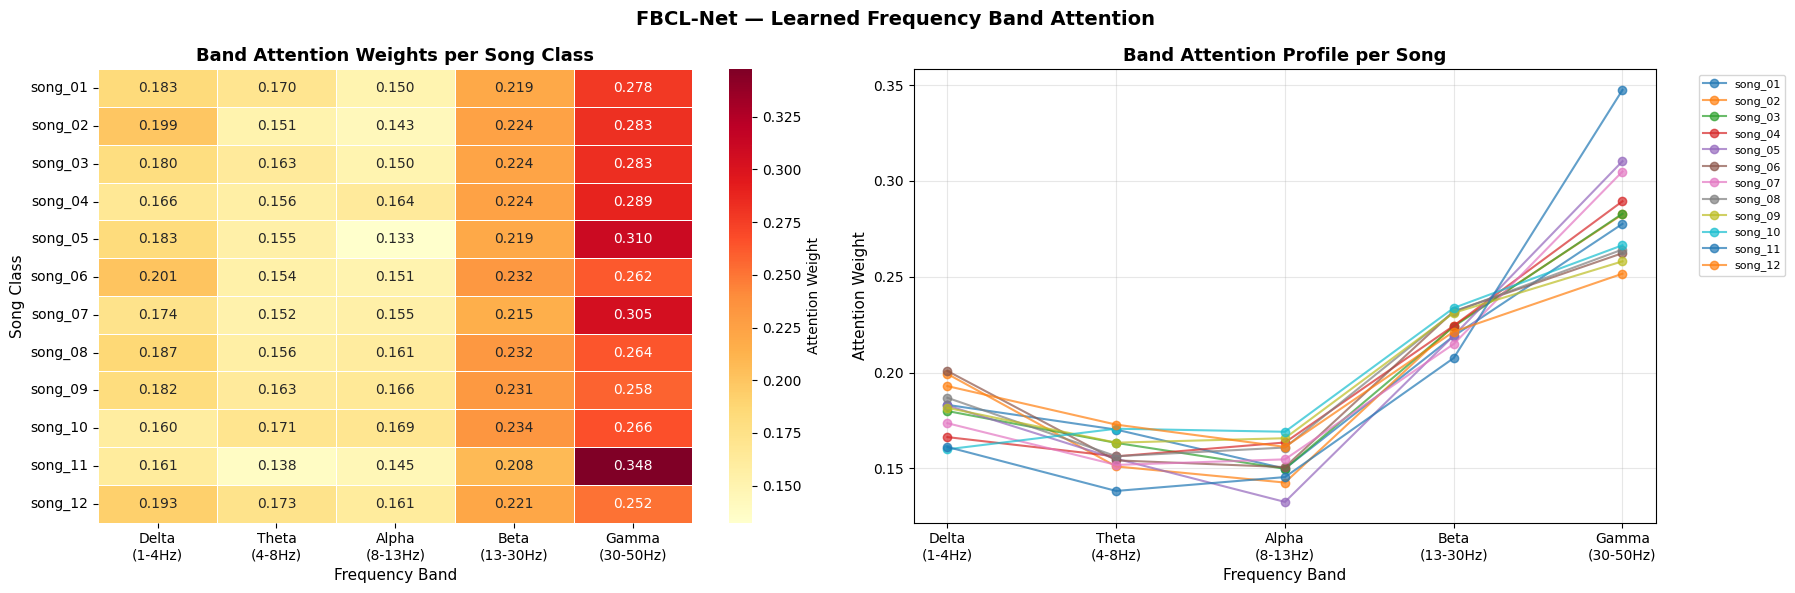

Saved → /content/drive/MyDrive/EEG_results_v2/band_attention.png


In [18]:
# ── CELL 14: Band Attention Visualization (Paper Figure) ─────────────────────
BAND_NAMES = ["Delta\n(1-4Hz)", "Theta\n(4-8Hz)",
              "Alpha\n(8-13Hz)", "Beta\n(13-30Hz)", "Gamma\n(30-50Hz)"]

# Collect band attention weights per class
fbcl.eval()
class_weights = {i: [] for i in range(n_classes)}

with torch.no_grad():
    for X_b, y_b in test_loader:
        _, _, band_w = fbcl(X_b.to(DEVICE), return_projection=True)
        for i, label in enumerate(y_b.numpy()):
            class_weights[label].append(band_w[i].cpu().numpy())

# Average per class
avg_weights = np.array([
    np.mean(class_weights[i], axis=0) for i in range(n_classes)
])  # (n_classes, 5)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap
sns.heatmap(avg_weights, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=BAND_NAMES,
            yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5,
            cbar_kws={"label": "Attention Weight"})
axes[0].set_title("Band Attention Weights per Song Class",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Frequency Band", fontsize=11)
axes[0].set_ylabel("Song Class",     fontsize=11)

# Line plot — each song's band preference
for i, song in enumerate(le.classes_):
    axes[1].plot(BAND_NAMES, avg_weights[i],
                 marker="o", label=song, alpha=0.7)
axes[1].set_title("Band Attention Profile per Song",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Frequency Band", fontsize=11)
axes[1].set_ylabel("Attention Weight", fontsize=11)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("FBCL-Net — Learned Frequency Band Attention",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/band_attention.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {SAVE_DIR}/band_attention.png")

Running t-SNE (this takes ~1-2 min)...


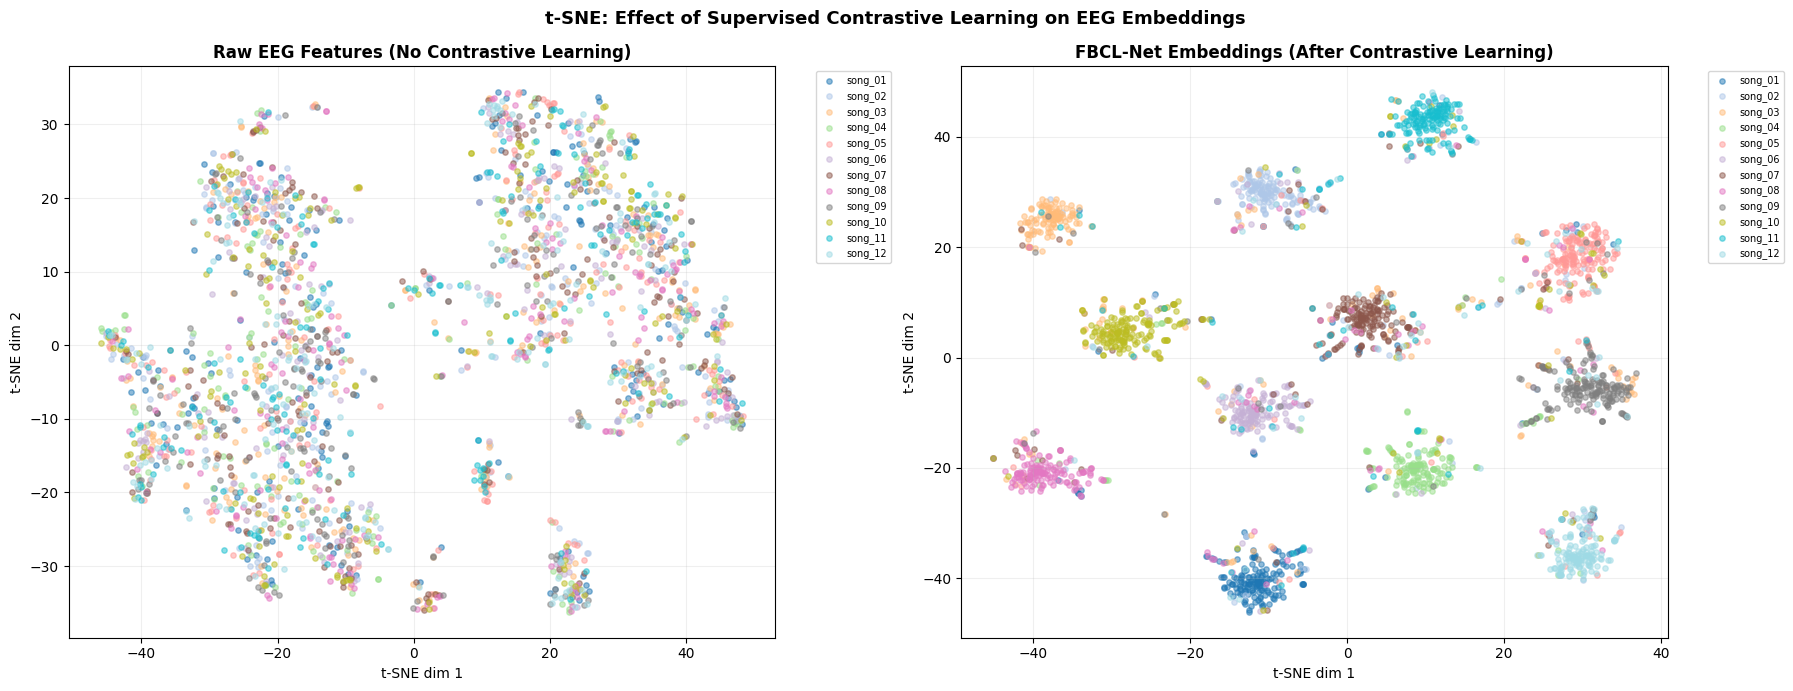

Saved → /content/drive/MyDrive/EEG_results_v2/tsne_comparison.png


In [19]:
# ── CELL 15: t-SNE — Before vs After Contrastive Learning ────────────────────
from sklearn.manifold import TSNE

# Extract embeddings from FBCL-Net projection head
fbcl.eval()
all_projs, all_raw, all_labels = [], [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b = X_b.to(DEVICE)
        _, proj, _ = fbcl(X_b, return_projection=True)
        all_projs.append(proj.cpu().numpy())
        all_raw.append(X_b.cpu().numpy())
        all_labels.extend(y_b.numpy())

projs  = np.vstack(all_projs)    # contrastive embeddings
raw    = np.vstack(all_raw)       # raw features
labels = np.array(all_labels)

print("Running t-SNE (this takes ~1-2 min)...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=40, n_iter=1000)
emb_proj = tsne.fit_transform(projs)

tsne2    = TSNE(n_components=2, random_state=SEED, perplexity=40, n_iter=1000)
emb_raw  = tsne2.fit_transform(raw[:, :200])  # use first 200 raw features

# Plot
colors = plt.cm.get_cmap("tab20", n_classes)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, emb, title in [
    (axes[0], emb_raw,  "Raw EEG Features (No Contrastive Learning)"),
    (axes[1], emb_proj, "FBCL-Net Embeddings (After Contrastive Learning)"),
]:
    for i, song in enumerate(le.classes_):
        mask = labels == i
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[colors(i)], label=song, alpha=0.5, s=15)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
    ax.grid(alpha=0.2)

plt.suptitle("t-SNE: Effect of Supervised Contrastive Learning on EEG Embeddings",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/tsne_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {SAVE_DIR}/tsne_comparison.png")

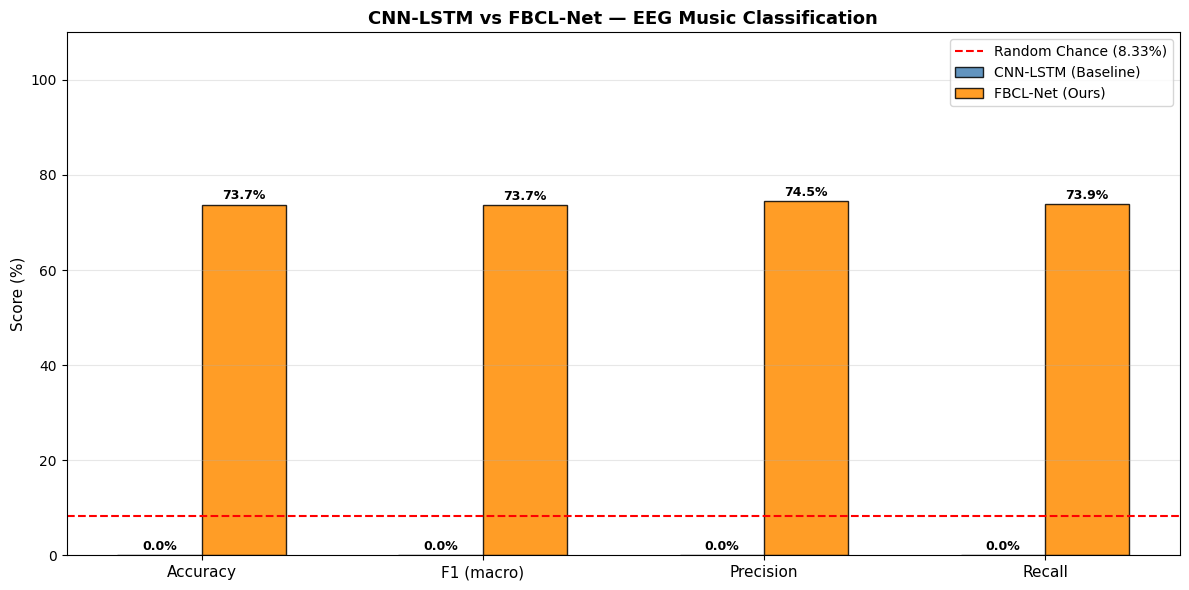


Metric            Random   CNN-LSTM   FBCL-Net
Accuracy           8.33%      0.00%      73.73%
F1 (macro)         8.33%      0.00%      73.69%
Precision          8.33%      0.00%      74.46%
Recall             8.33%      0.00%      73.91%

✅ FBCL-Net improvement over CNN-LSTM: +73.73% accuracy
Figures saved to: /content/drive/MyDrive/EEG_results_v2


In [20]:
# ── CELL 16: Final Summary Plot ───────────────────────────────────────────────
metric_names = ["Accuracy", "F1 (macro)", "Precision", "Recall"]
x     = np.arange(len(metric_names))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2,
               [m_cnn[m]  for m in metric_names],
               width, label="CNN-LSTM (Baseline)",
               color="steelblue", alpha=0.85, edgecolor="black")
bars2 = ax.bar(x + width/2,
               [m_fbcl[m] for m in metric_names],
               width, label="FBCL-Net (Ours)",
               color="darkorange", alpha=0.85, edgecolor="black")

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(y=8.33, color="red", linestyle="--",
           linewidth=1.5, label="Random Chance (8.33%)")
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_ylim(0, 110)
ax.set_title("CNN-LSTM vs FBCL-Net — EEG Music Classification",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/final_comparison.png", dpi=150)
plt.show()

# Print final table
print("\n" + "=" * 58)
print(f"{'Metric':<15} {'Random':>8} {'CNN-LSTM':>10} {'FBCL-Net':>10}")
print("=" * 58)
for m in metric_names:
    print(f"{m:<15} {'8.33%':>8} {m_cnn[m]:>9.2f}%  {m_fbcl[m]:>9.2f}%")
print("=" * 58)
print(f"\n✅ FBCL-Net improvement over CNN-LSTM: "
      f"{m_fbcl['Accuracy'] - m_cnn['Accuracy']:+.2f}% accuracy")
print(f"Figures saved to: {SAVE_DIR}")

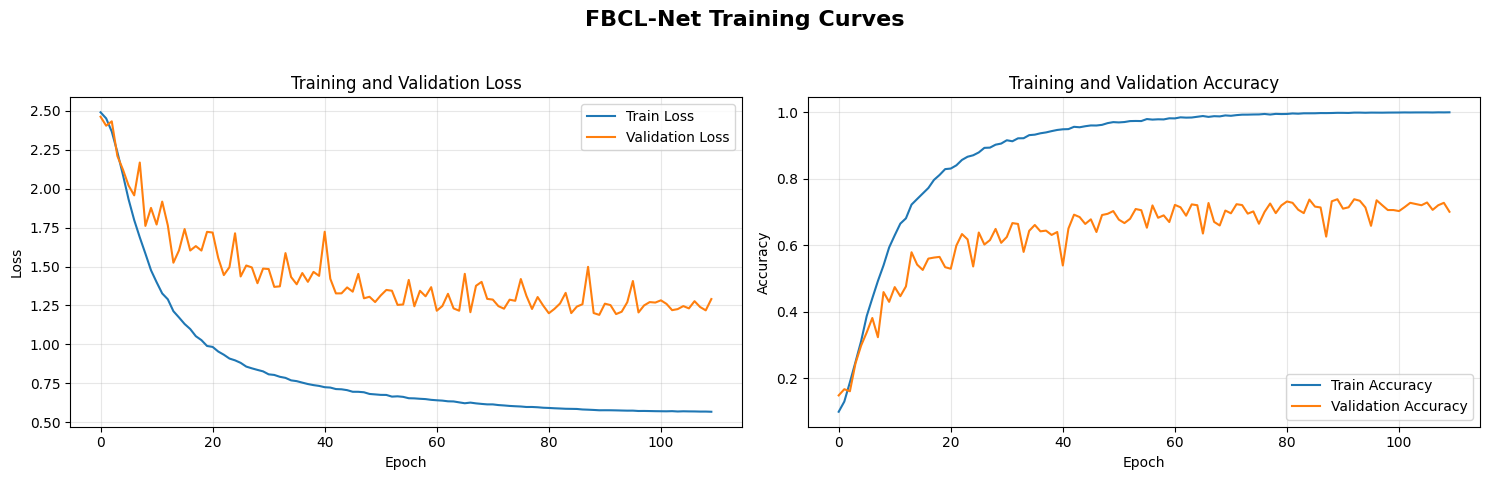

Saved → /content/drive/MyDrive/EEG_results_v2/training_curves.png


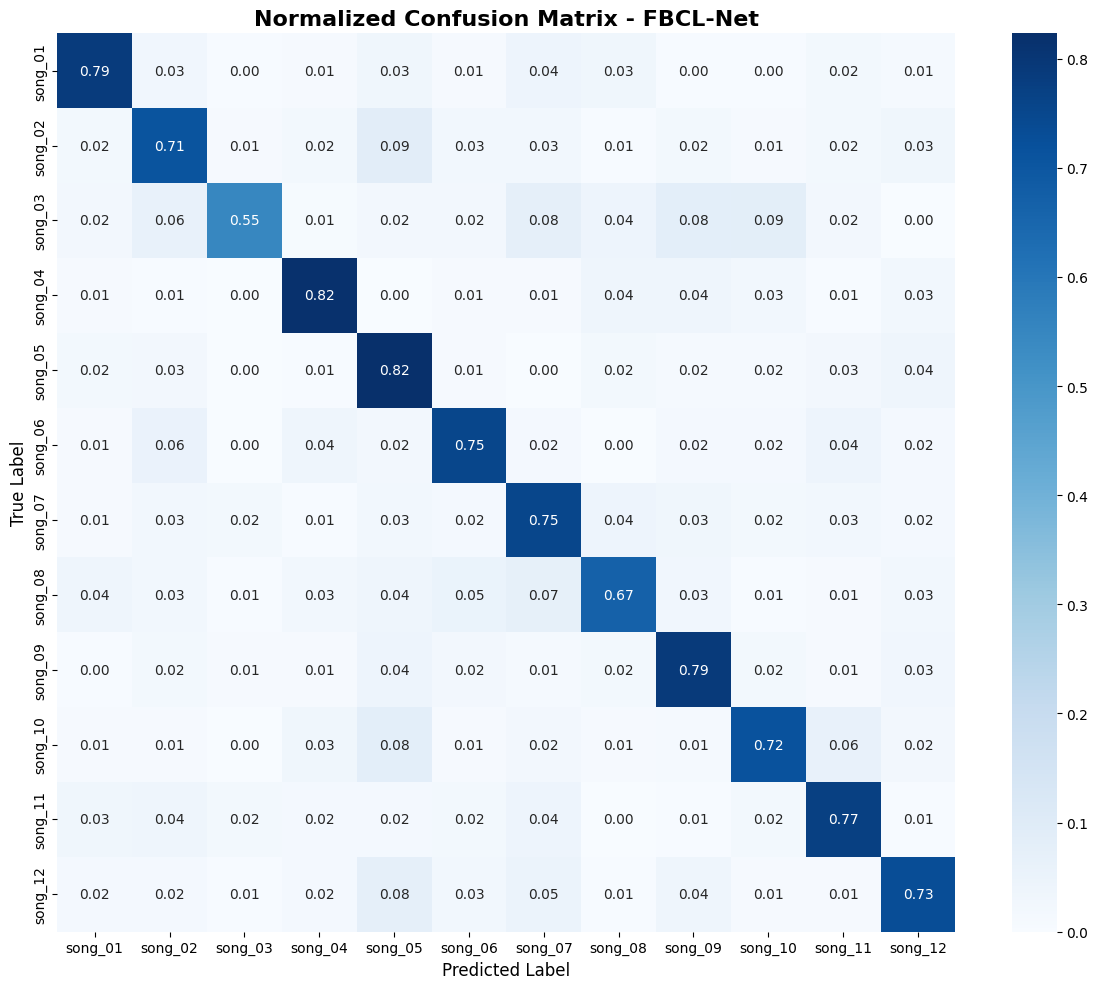

Saved → /content/drive/MyDrive/EEG_results_v2/confusion_matrix.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Training Plots

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('FBCL-Net Training Curves', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150)
plt.show()
print(f"Saved → {SAVE_DIR}/training_curves.png")

# 2. Confusion Matrix

cm = confusion_matrix(fbcl_true, fbcl_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Normalized Confusion Matrix - FBCL-Net', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png", dpi=150)
plt.show()
print(f"Saved → {SAVE_DIR}/confusion_matrix.png")
